In [1]:
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 17.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.4 MB/s eta 0:00:00:00:01


In [2]:
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

In [3]:
path = untar_data(URLs.MNIST_SAMPLE)
path

<div><progress max="3214948" value="3219456"></progress> 100.14% [3219456/3214948 00:00&lt;00:00]</div>

Path('/root/.fastai/data/mnist_sample')

In [4]:
path.ls()

[Path('/root/.fastai/data/mnist_sample/valid'), Path('/root/.fastai/data/mnist_sample/labels.csv'), Path('/root/.fastai/data/mnist_sample/train')]

In [5]:
Path.BASE_PATH = path
Path.BASE_PATH

Path('.')

In [6]:
path

Path('.')

In [7]:
path.ls()

[Path('valid'), Path('labels.csv'), Path('train')]

In [8]:
(path/'train').ls()

[Path('train/7'), Path('train/3')]

In [9]:
threes = (path/'train/3').ls().sorted()
sevens = (path/'train/7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'), Path('train/3/10000.png'), Path('train/3/10011.png'), Path('train/3/10031.png'), Path('train/3/10034.png'), Path('train/3/10042.png'), Path('train/3/10052.png'), Path('train/3/1007.png'), Path('train/3/10074.png'), Path('train/3/10091.png'), Path('train/3/10093.png'), Path('train/3/10097.png'), Path('train/3/10099.png'), Path('train/3/10116.png'), Path('train/3/10125.png'), Path('train/3/10137.png'), Path('train/3/10141.png'), Path('train/3/10144.png'), Path('train/3/10155.png'), Path('train/3/10161.png'), Path('train/3/10206.png'), Path('train/3/1021.png'), Path('train/3/10210.png'), Path('train/3/10214.png'), Path('train/3/10238.png'), Path('train/3/10260.png'), Path('train/3/10278.png'), Path('train/3/10282.png'), Path('train/3/10314.png'), Path('train/3/10322.png'), Path('train/3/10328.png'), Path('train/3/10329.png'), Path('train/3/10330.png'), Path('train/3/10349.png'), Path('train/3/1035.png'), Path('train/3/10360.png'), Path('train/3/10369.png')

In [10]:
img3_path = threes[1]
img = Image.open(img3_path)
img

In [11]:
array(img)[4:10, 4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

In [12]:
tensor(img)[4:10, 4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

In [13]:
img_t = tensor(img)
df = pd.DataFrame(img_t[4:15, 4:22])
df.style.set_properties(**{'font-size': '6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0


In [14]:
sevens_tensors = [tensor(Image.open(p)) for p in sevens]
threes_tensors = [tensor(Image.open(p)) for p in threes]
len(sevens_tensors),len(threes_tensors)

(6265, 6131)

<Axes: >

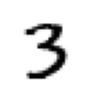

In [15]:
show_image(threes_tensors[1])

In [16]:
stacked_sevens = torch.stack(sevens_tensors).float()/255
stacked_threes = torch.stack(threes_tensors).float()/255
stacked_sevens.shape, stacked_threes.shape

(torch.Size([6265, 28, 28]), torch.Size([6131, 28, 28]))

In [17]:
stacked_threes.ndim

3

<Axes: >

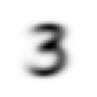

In [18]:
mean3 = stacked_threes.mean(0)
show_image(mean3)

<Axes: >

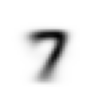

In [19]:
mean7 = stacked_sevens.mean(0)
show_image(mean7)

In [20]:
mean7.shape

torch.Size([28, 28])

In [21]:
a3 = stacked_threes[1]
mad_a3 = (a3 - mean3).abs().mean()
rmse_a3 = (a3 - mean3).pow(2).mean().sqrt()

mad_a3, rmse_a3

(tensor(0.1114), tensor(0.2021))

In [22]:
mad_a7 = (a3 - mean7).abs().mean()
rmse_a7 = (a3 - mean7).pow(2).mean().sqrt()

mad_a7, rmse_a7

(tensor(0.1586), tensor(0.3021))

In [23]:
F.l1_loss(a3.float(), mean3), F.mse_loss(a3.float(), mean3).sqrt()

(tensor(0.1114), tensor(0.2021))

In [24]:
F.l1_loss(a3.float(), mean7), F.mse_loss(a3.float(), mean7).sqrt()

(tensor(0.1586), tensor(0.3021))

In [25]:
(path/'valid').ls()

[Path('valid/7'), Path('valid/3')]

In [26]:
valid_3_tens = torch.stack([tensor(Image.open(p)) for p in (path/'valid/3').ls().sorted()])
valid_3_tens

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

<Axes: >

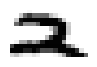

In [27]:
show_image(valid_3_tens[1][4:15, 4:22])

In [28]:
valid_7_tens = torch.stack([tensor(Image.open(p)) for p in (path/'valid/7').ls().sorted()])
valid_7_tens

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

<Axes: >

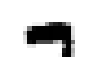

In [29]:
show_image(valid_7_tens[1][4:15, 4:22])

In [30]:
valid_3_tens = valid_3_tens.float()/255
valid_7_tens = valid_7_tens.float()/255
valid_3_tens, valid_7_tens

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         ...,
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 

In [31]:
valid_3_tens.shape, valid_7_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

In [32]:
def mnist_dist(img: tensor, target: tensor) -> float:
    return (img - target).abs().mean((-1, -2))

In [33]:
mnist_dist(a3, mean3), mnist_dist(a3, mean7)

(tensor(0.1114), tensor(0.1586))

In [34]:
valid_3_dist = mnist_dist(valid_3_tens, mean3)
valid_3_dist, valid_3_dist.shape

(tensor([0.1280, 0.1623, 0.1242,  ..., 0.1508, 0.1263, 0.1260]),
 torch.Size([1010]))

In [35]:
def is_3(img: tensor):
    return mnist_dist(img, mean3) < mnist_dist(img, mean7)

In [36]:
is_3(a3)

tensor(True)

In [37]:
is_3(valid_3_tens)

tensor([ True,  True,  True,  ..., False,  True,  True])

In [38]:
is_3(valid_7_tens)

tensor([False, False, False,  ..., False, False, False])

In [39]:
accuracy_3 = is_3(valid_3_tens).float().mean()
accuracy_7 = (1 - is_3(valid_7_tens).float()).mean()

accuracy_3, accuracy_7, (accuracy_3 + accuracy_7) / 2

(tensor(0.9168), tensor(0.9854), tensor(0.9511))

In [42]:
def loss_fn(wt: tensor):
    """Accepts weight and calculates loss using real x and y pairs. Simplified to assume loss is modeled by x**2"""
    return wt**2

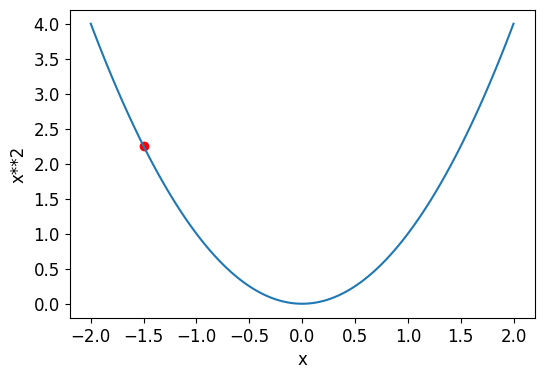

In [43]:
plot_function(loss_fn, 'x', 'x**2')
plt.scatter(-1.5, loss_fn(-1.5), color='red')

In [44]:
# generate a tensor representing a weight value
# use requires_grad_ to prepare pytorch to calculate the gradient for operations involving this tensor
xt = tensor(3.).requires_grad_()
xt

tensor(3., requires_grad=True)

In [45]:
# use the tensor in a function
yt = loss_fn(xt)
yt

tensor(9., grad_fn=<PowBackward0>)

In [46]:
# now calculate the gradient for that coordinate in the curve of the function
# i.e. the gradient where the input (independent variable) is the tensor
# i.e. the value of the derivative where the value of the dependent variable is the tensor
yt.backward() # notice that we're calculating this from the output of the function's invocation, which is where pytorch can track which derivative to apply
xt.grad # the gradient is stored on the tensor, not sure why

tensor(6.)

In [47]:
# illustrate the same process using a vector (rank-1 tensor)
xt = tensor([3., 4., 10.]).requires_grad_()
xt

tensor([ 3.,  4., 10.], requires_grad=True)

In [48]:
# modify the loss function to work return a scalar from the vector
def loss_fn(wt):
    return wt.pow(2).sum()

In [49]:
yt = loss_fn(xt)
yt

tensor(125., grad_fn=<SumBackward0>)

In [50]:
yt.backward()
xt.grad

tensor([ 6.,  8., 20.])